# 🩺 Diabetes Risk Prediction

## Project Overview
This project builds a machine learning model to predict diabetes risk based on patient health data.
The dataset contains 100,000 records with features like age, BMI, HbA1c level, and blood glucose.

## Key Findings
- **HbA1c** and **Blood Glucose** are the strongest predictors of diabetes
- Diabetes risk increases significantly after age 30
- Higher BMI is associated with higher diabetes risk

## Model
- Algorithm: Random Forest Classifier
- ROC-AUC: 0.9684
- Handled class imbalance using SMOTE

# Data overview

In [1]:
import numbers as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df= pd.read_csv(r"C:\Users\b.k\Colab Notebooks\projects\diabetes_prediction project\diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 📊 Exploratory Data Analysis (EDA)

The dataset has no missing values. Key observations:
- **91.5%** of patients have no diabetes — imbalanced dataset
- Diabetes appears more frequently in patients **above age 30**
- Patients with diabetes have **higher BMI** on average
- **HbA1c** and **Blood Glucose** show the strongest correlation with diabetes

In [2]:
df.shape

(100000, 9)

In [3]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [4]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [5]:
print(df['diabetes'].value_counts(),"\n")

print(df['diabetes'].value_counts(normalize=True)*100)


diabetes
0    91500
1     8500
Name: count, dtype: int64 

diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


In [6]:
print(df["gender"].value_counts(),"\n")
print(df["smoking_history"].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64 

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [7]:
df['gender'] = df['gender'].replace('Other','Male')
df['smoking_history'] = df['smoking_history'].replace('No Info', 'unknown')
print(df[['smoking_history','gender']].value_counts())


smoking_history  gender
never            Female    22869
unknown          Female    19700
                 Male      16116
never            Male      12226
current          Female     5058
former           Female     4774
                 Male       4578
current          Male       4228
not current      Female     3913
                 Male       2534
ever             Female     2238
                 Male       1766
Name: count, dtype: int64


C:\Users\b.k\AppData\Local\Temp\ipykernel_15824\2077880034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='diabetes',palette='Set2',edgecolor="black")


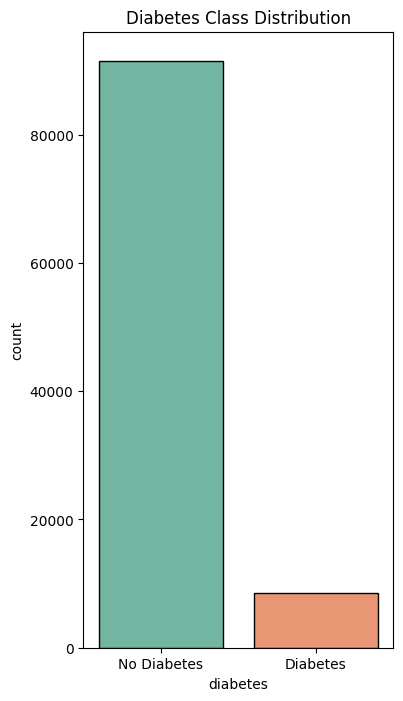

In [8]:
plt.figure(figsize=(4,8))
sns.countplot(data=df,x='diabetes',palette='Set2',edgecolor="black")
plt.title('Diabetes Class Distribution')
plt.xticks([0,1],['No Diabetes', 'Diabetes'])
plt.savefig('class_disttibution.png',dpi=300)
plt.show()

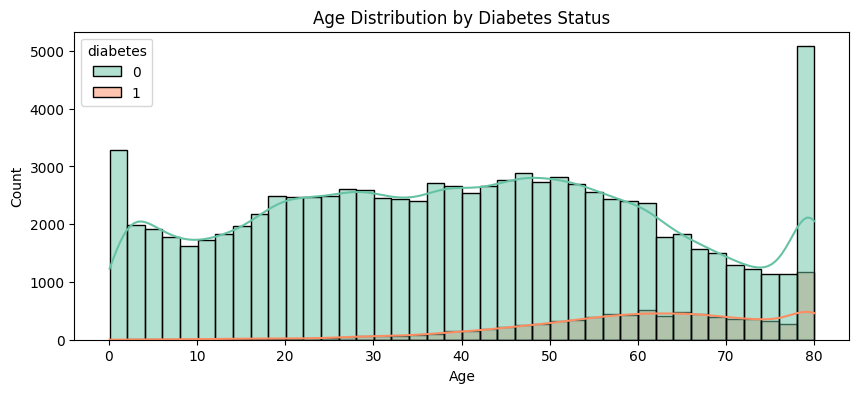

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', hue='diabetes', bins=40, kde=True, palette='Set2')
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Age')
plt.savefig('age_distribution.png', dpi=300)
plt.show()

C:\Users\b.k\AppData\Local\Temp\ipykernel_15824\2046075511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='diabetes',y='bmi',palette='Set2')


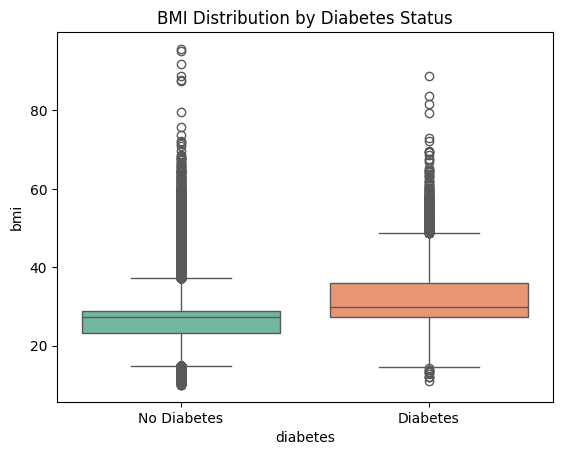

In [10]:
plt.Figure(figsize=(10,4))
sns.boxplot(data=df,x='diabetes',y='bmi',palette='Set2')
plt.title('BMI Distribution by Diabetes Status')
plt.xticks([0,1],['No Diabetes', 'Diabetes'])
plt.savefig('age_distribution.png', dpi=300)
plt.show()

C:\Users\b.k\AppData\Local\Temp\ipykernel_15824\3040626604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes', y='HbA1c_level', palette='Set2', ax=axes[0])
C:\Users\b.k\AppData\Local\Temp\ipykernel_15824\3040626604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', palette='Set2', ax=axes[1])


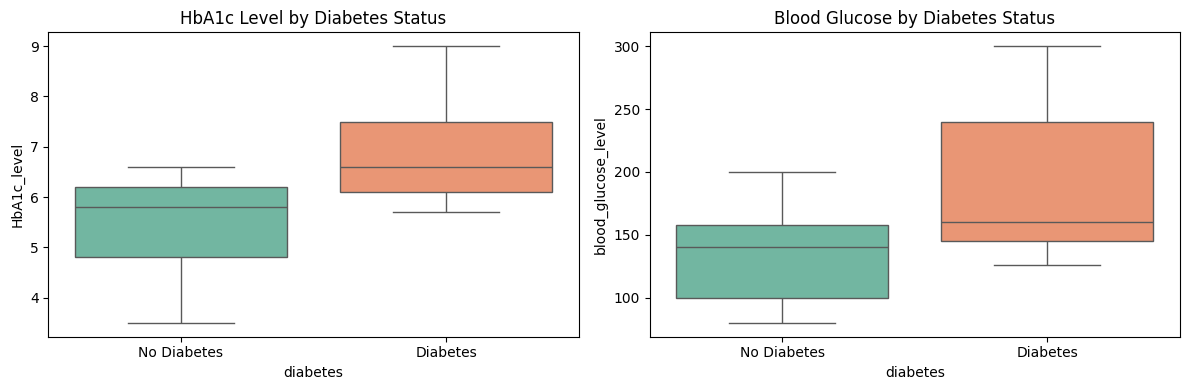

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='diabetes', y='HbA1c_level', palette='Set2', ax=axes[0])
axes[0].set_title('HbA1c Level by Diabetes Status')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'])

sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', palette='Set2', ax=axes[1])
axes[1].set_title('Blood Glucose by Diabetes Status')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.savefig('medical_features.png', dpi=300)
plt.show()

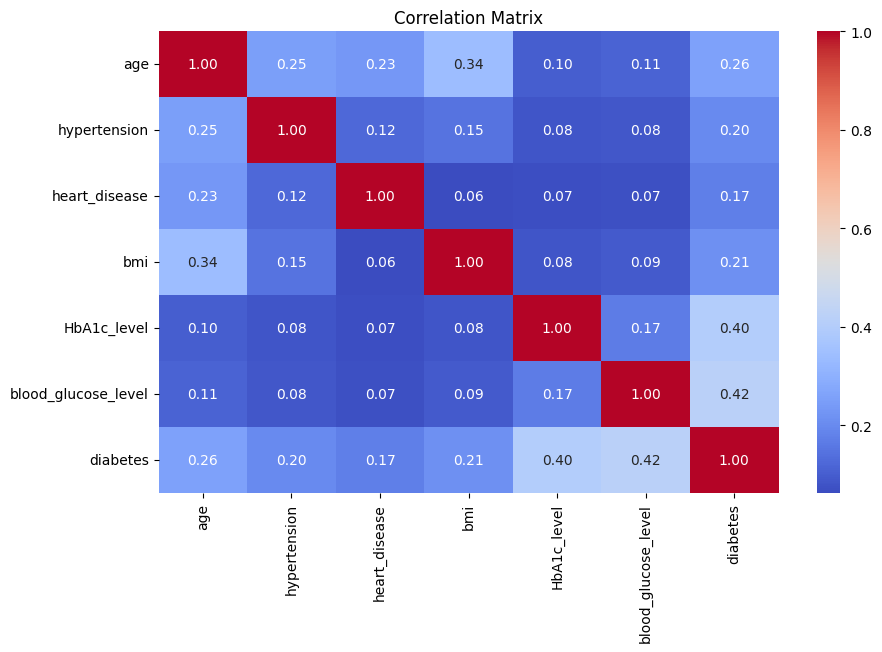

In [12]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# 🔧 Preprocessing

Steps taken to prepare the data for modeling:
- Replaced **'Other'** gender with **'Male'** to preserve data size (only 18 records)
- Replaced **'No Info'** in smoking history with **'unknown'** as a valid category
- Applied **Label Encoding** to categorical features
- Applied **StandardScaler** to normalize numerical features


In [13]:
import sklearn

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['smoking_history']=le.fit_transform(df['smoking_history'])

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,3,25.19,6.6,140,0
1,0,54.0,0,0,5,27.32,6.6,80,0
2,1,28.0,0,0,3,27.32,5.7,158,0
3,0,36.0,0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,0,20.14,4.8,155,0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=df.drop(columns='diabetes')
y=df['diabetes']

x_trian , x_test , y_train , y_test =train_test_split(x,y, test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_trian)
x_test = scaler.transform(x_test)

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)



Train size: (80000, 8)
Test size: (20000, 8)


# 🤖 Model Building & Evaluation

Trained and compared two models:
- **Logistic Regression**
- **Random Forest Classifier**
- Used **SMOTE** to handle class imbalance (8.5% diabetes cases)
## Why Random Forest?
Higher ROC-AUC (0.9684) and better Precision (0.77) — more reliable predictions in medical applications.

### Results after SMOTE
| Metric | Value |
|--------|-------|
| ROC-AUC | 0.9684 |
| Recall (Diabetes) | 0.75 |
| Precision (Diabetes) | 0.77 |

### Key Insight
In medical prediction, **Recall is more important than Precision** —
it's better to flag a healthy person for tests than to miss a real diabetes case.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report ,roc_auc_score

models={
    'LogisticRegression' : LogisticRegression(max_iter=1000),
    'RandomForestClassifier' : RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
}

for name, model in models.items(): 
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(f"\n{'='*40}")   
    print(f'Model: {name}')
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(x_test)[:,1]):.4f}")


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.87      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.92      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000

ROC-AUC: 0.9615

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

ROC-AUC: 0.9662


In [16]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
x_train_sm ,y_train_sm =smote.fit_resample(x_train,y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 73208, 1: 6792}
After SMOTE: {0: 73208, 1: 73208}


In [17]:
for name, model in models.items():
    model.fit(x_train_sm, y_train_sm)
    y_pred = model.predict(x_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(x_test)[:,1]):.4f}")


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18292
           1       0.43      0.88      0.58      1708

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.91     20000

ROC-AUC: 0.9619

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18292
           1       0.77      0.75      0.76      1708

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.87     20000
weighted avg       0.96      0.96      0.96     20000

ROC-AUC: 0.9684


C:\Users\b.k\AppData\Local\Temp\ipykernel_15824\2434356194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='coolwarm')


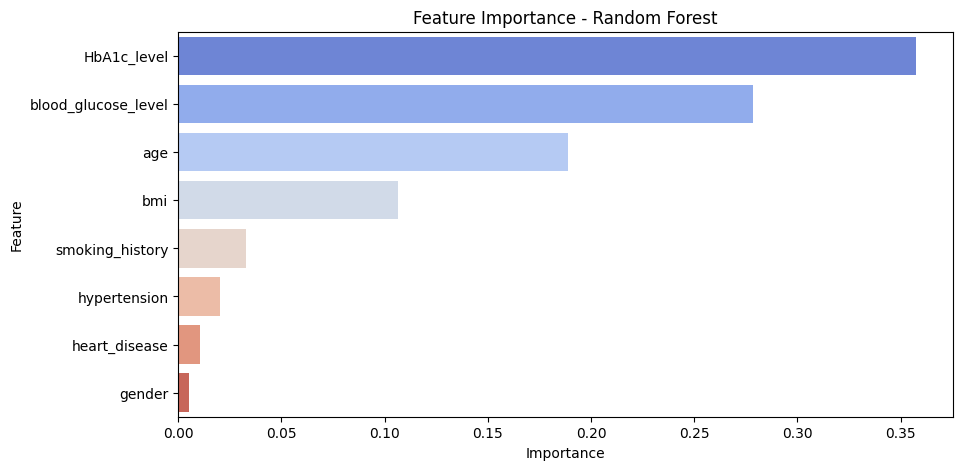

In [18]:
model_rf = models['RandomForestClassifier']

feature_names = df.drop(columns=['diabetes']).columns
importances = model_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='coolwarm')
plt.title('Feature Importance - Random Forest')
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Save Model


In [19]:
import joblib

joblib.dump(model_rf, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully! ✅")

Model saved successfully! ✅


# ✅ Conclusion

This project successfully built a diabetes risk prediction model with:
- **ROC-AUC: 0.9684**
- **Recall: 0.75** on diabetes cases
- **Precision: 0.77** on diabetes cases

### What I Learned
- How to handle imbalanced datasets using SMOTE
- Importance of Recall over Accuracy in medical ML
- Feature importance analysis using model coefficients

### Next Steps
- Try XGBoost for potentially better performance
- Collect more diverse data to improve generalization